In [1]:
import pandas as pd
import numpy as np
from datetime import timedelta
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')  # Suppress warnings for cleaner output

# 1. Load Data & Create Target
df = pd.read_excel('Individual Assignment Data File Electronic_sales.xlsx')
df.shape


(20000, 16)

In [10]:
# Convert Purchase Date to datetime objects
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

# Establish anchor date (typically 1 day after the most recent purchase in the dataset)
anchor_date = df['Purchase Date'].max() + timedelta(days=1)

# Calculate the Monetary value defined as Total Price + Add-on Total
df['Total Value'] = df['Total Price'] + df['Add-on Total']

# Aggregate at the Customer level
# Note: If an explicit 'Order ID' column is missing, row count ('Customer ID': 'count') 
# or unique dates ('Purchase Date': 'nunique') serves as a proxy for Frequency.
rfm = df.groupby('Customer ID').agg({
    'Purchase Date': lambda x: (anchor_date - x.max()).days,  # Recency
    'Customer ID': 'count',                                   # Frequency
    'Total Value': 'sum'                                      # Monetary
}).rename(columns={
    'Purchase Date': 'Recency',
    'Customer ID': 'Frequency',
    'Total Value': 'Monetary'
})

In [11]:
# Standardize the RFM metrics to ensure equal weighting for K-Means
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

# Apply K-Means clustering
# We'll use 4 clusters (e.g., Champions, Loyal Customers, At-Risk, Hibernating)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

# View the centroids to help label the cohorts based on business logic
cluster_centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_), 
                               columns=['Recency', 'Frequency', 'Monetary'])
print("--- Cluster Centroids (Unscaled) ---")
print(cluster_centers.round(2))
print("\n")

--- Cluster Centroids (Unscaled) ---
   Recency  Frequency  Monetary
0    80.82       1.11   2968.57
1   245.11       1.15   3218.16
2    87.55       2.19   7105.41
3    64.17       3.34  14394.39




In [12]:
print("--- Loyalty Program Add-on Analysis ---")

# Separate groups
loyalty_yes = df[df['Loyalty Member'] == 'Yes']['Add-on Total'].fillna(0)
loyalty_no = df[df['Loyalty Member'] == 'No']['Add-on Total'].fillna(0)

# Calculate descriptive statistics
mean_add_on_yes = loyalty_yes.mean()
mean_add_on_no = loyalty_no.mean()

print(f"Mean Add-on Total (Loyalty Members): ${mean_add_on_yes:.2f}")
print(f"Mean Add-on Total (Standard Buyers): ${mean_add_on_no:.2f}")

# Perform an independent two-sample t-test (Welch's t-test for unequal variances)
t_stat, p_val = stats.ttest_ind(loyalty_yes, loyalty_no, equal_var=False)

print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_val:.4e}")

if p_val < 0.05:
    print("Conclusion: Loyalty members have a statistically significant higher propensity to spend on add-ons.")
else:
    print("Conclusion: No statistically significant difference in add-on spending between loyalty tiers.")

--- Loyalty Program Add-on Analysis ---
Mean Add-on Total (Loyalty Members): $62.31
Mean Add-on Total (Standard Buyers): $62.23
T-Statistic: 0.0820
P-Value: 9.3466e-01
Conclusion: No statistically significant difference in add-on spending between loyalty tiers.


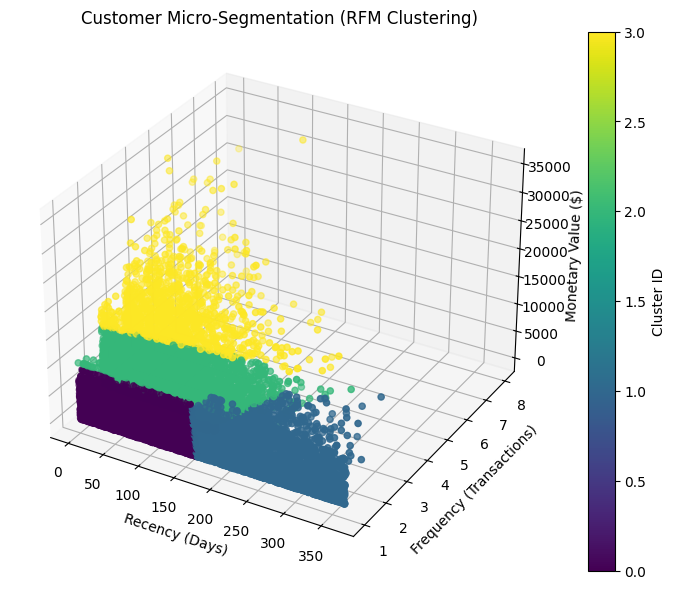

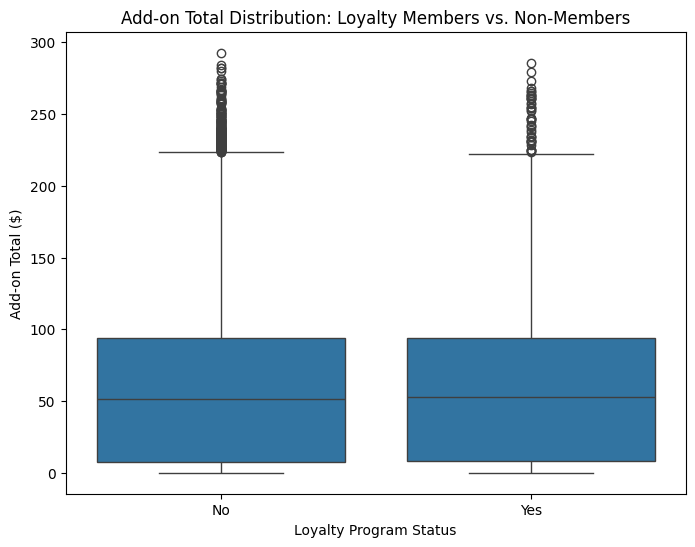

In [13]:
# Plot 1: 3D Scatter of RFM Clusters
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(rfm['Recency'], rfm['Frequency'], rfm['Monetary'], 
                     c=rfm['Cluster'], cmap='viridis', marker='o')
ax.set_xlabel('Recency (Days)')
ax.set_ylabel('Frequency (Transactions)')
ax.set_zlabel('Monetary Value ($)')
plt.title('Customer Micro-Segmentation (RFM Clustering)')
plt.colorbar(scatter, label='Cluster ID')
plt.show()

# Plot 2: Loyalty Member vs. Add-on Total Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Loyalty Member', y='Add-on Total', data=df)
plt.title('Add-on Total Distribution: Loyalty Members vs. Non-Members')
plt.ylabel('Add-on Total ($)')
plt.xlabel('Loyalty Program Status')
plt.show()